In [29]:
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.fft as fft
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
import matplotlib.pyplot as plt
import timm

import os
import time

from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

# -------------------------------
# 1. Configuration
# -------------------------------
IMAGENET_DIR = ""
SAVE_PATH = "zero/"
BATCH_SIZE = 32
NUM_WORKERS = 4
MAX_BATCHES = 2000
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# DEVICE = torch.device("cpu")
SEED = 42

In [3]:
def ploting_image(feats, image, model):
    L = len(feats)
    fig, axes = plt.subplots(1, L+1, figsize=(30, 10))
    axes[0].imshow(np.mean(image[-1].numpy(), axis=0), cmap='gray')
    for i, (name, feat) in enumerate(feats.items()):
        feat = model.patches_to_2d(feat).squeeze(0).mean(dim=-1)
        axes[i+1].imshow(feat[-1].cpu().numpy(), cmap='viridis')
        axes[i+1].set_title(f"Канал {i}")
        axes[i+1].axis('off')
    plt.show()

## Сохранненные спектры открыть

In [30]:
spectra_vit_t_16 = np.load(f'{SAVE_PATH}vit_t_16.npz', allow_pickle=True)
spectra_vit_s_16 = np.load(f'{SAVE_PATH}vit_s_16.npz', allow_pickle=True)
spectra_vit_b_16 = np.load(f'{SAVE_PATH}vit_b_16.npz', allow_pickle=True)
spectra_vit_l_16 = np.load(f'{SAVE_PATH}vit_l_16.npz', allow_pickle=True)

models_dict = {
    "Tiny": spectra_vit_t_16,
    "Small": spectra_vit_s_16,
    "Base": spectra_vit_b_16,
    "Large": spectra_vit_l_16
}
markers = {
    "Tiny": "s",
    "Small": "o",
    "Base": "<",
    "Large": "d"
}

## Функции для извлечения спектров

In [5]:


import os
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
os.environ['HTTP_TIMEOUT'] = '120' 

# -------------------------------
# 2. Reproducibility
# -------------------------------
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

set_seed(SEED)

# -------------------------------
# 3. ImageNet DataLoader
# -------------------------------
def get_imagenet_val_loader(data_dir, batch_size, num_workers):
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        normalize,
    ])
    val_dataset = datasets.ImageFolder(root="imagenet", transform=val_transform)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size,
                                             shuffle=False, num_workers=num_workers, pin_memory=True)
    return val_loader

# -------------------------------
# 4. Spectral Analysis Functions
# -------------------------------
def compute_fft_power(feat):
    feat = feat.float()
    F2 = fft.fft2(feat, norm="ortho")
    F2_shift = fft.fftshift(F2, dim=(-2, -1))
    power = torch.abs(F2_shift) ** 2
    power_mean = power.mean(dim=(0, 1))  # [H, W]
    return power_mean.cpu()

def radial_average(power_2d):
    H, W = power_2d.shape
    cy, cx = H // 2, W // 2
    y = np.arange(H) - cy
    x = np.arange(W) - cx
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)
    R_int = R.astype(np.int32)

    r_max = R_int.max()
    radial_sum = np.zeros(r_max + 1, dtype=np.float64)
    radial_count = np.zeros(r_max + 1, dtype=np.int64)

    power_np = power_2d.numpy()
    for r in range(r_max + 1):
        mask = (R_int == r)
        radial_sum[r] = power_np[mask].sum()
        radial_count[r] = mask.sum()

    radial_mean = np.zeros_like(radial_sum)
    nonzero = radial_count > 0
    radial_mean[nonzero] = radial_sum[nonzero] / radial_count[nonzero]

    s = radial_mean.sum()
    if s > 0:
        radial_mean = radial_mean / s
        
    return radial_mean

# -------------------------------
# 5. Hooked Model
# -------------------------------
class HookedVit(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.model.eval()
        self.features = {}

        self.patch_size = self.model.patch_embed.patch_size[1]
        self.num_patches = self.model.patch_embed.num_patches
        self.grid_size = int(np.sqrt(self.num_patches))

        self.has_cls_token = hasattr(self.model, 'cls_token') and self.model.cls_token is not None

        total_blocks = len(self.model.blocks)
        for idx, block in enumerate(self.model.blocks):
            # if idx in [0, total_blocks//4, total_blocks//2, 3*total_blocks//4, total_blocks-1]:
            block.register_forward_hook(self.hook_fn(f"block_{idx}"))

    def hook_fn(self, name):
            def fn(module, input, output):
                self.features[name] = output.detach()
            return fn

    def forward(self, x):
        self.features = {}
        return self.model(x)

    def get_features(self):
        return self.features

    def patches_to_2d(self,patch_features):

        if self.has_cls_token:
            # CLS токен всегда первый (индекс 0)
            patch_features = patch_features[:, 1:, :]  # удаляем CLS токен
            N = patch_features.shape[1]
        
        B, N, D = patch_features.shape
        H = self.grid_size
        W = self.grid_size
        # if N != H * W:
        #     raise ValueError(f"Number of patches {N} doesn't match grid {H}x{W}={H*W}")
        # Решейп в (B, H, W, D)
        return patch_features.view(B, H, W, D)

# -------------------------------
# 6. Run Spectral Analysis
# -------------------------------
def collect_spectra(model, loader, device, max_batches, image_plot=None):
    model.eval()
    spectra = {}
    processed = 0

    with torch.no_grad():
        cnt = 0
        for images, _ in loader:
            cnt += 1
            if cnt%40==2: print(f'{cnt} ')
            images = images.to(device)
           
            _ = model(images) 
            
            feats = model.get_features()
            if image_plot:
                ploting_image(feats, images, model)
            
            for name, feat in feats.items():
                # feat: (B, N, D)
                # Преобразуем в 2D карту (B, H, W, D)
                feat_2d = model.patches_to_2d(feat)
                
                # Вычитаем среднее по пространству (H, W) для каждого канала
                spatial_mean = feat_2d.mean(dim=(1, 2), keepdim=True)  # (B, 1, 1, D)
                feat_centered = feat_2d - spatial_mean
                
                # Меняем форму для compute_fft_power: из (B, H, W, D) в (B, D, H, W)
                # потому что compute_fft_power ожидает (B, C, H, W)
                feat_centered = feat_centered.permute(0, 3, 1, 2)  # (B, D, H, W)

                # Считаем спектр (используем ту же функцию, что для ResNet)
                power_2d = compute_fft_power(feat_centered)  # (H, W)
                
                # Радиальное усреднение
                curve = radial_average(power_2d)
                spectra.setdefault(name, []).append(curve)

            if cnt >= max_batches:
                break

    mean_spectra = {}
    for name, curves in spectra.items():
        try:
            min_len = min(c.shape[0] for c in curves)
            aligned = np.stack([c[:min_len] for c in curves], axis=0)
            mean_curve = aligned.mean(axis=0)
            mean_spectra[name] = mean_curve
        except:
            mean_spectra[name] = curves
            print(curves)
        
    return mean_spectra


In [5]:
val_loader = get_imagenet_val_loader(IMAGENET_DIR, 20, NUM_WORKERS)
base_small_model = timm.create_model('vit_small_patch16_224', pretrained=True).to(DEVICE)
small_model = HookedVit(base_small_model).to(DEVICE)
collect_spectra(small_model, val_loader, DEVICE, 10)

/home/shamighoul/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


2 


KeyboardInterrupt: 

## Функции для графиков и метрик

In [31]:
def plot_spectra(spectra_dict, save_path=None):
    plt.style.use("seaborn-v0_8")
    fig, axs = plt.subplots(3, 2, figsize=(12, 15))
    axs = axs.ravel()
    blocks = sorted(spectra_dict.keys(), key=lambda x: int(x.split('_')[1]))
    
    for i, blk in enumerate(blocks):
        if blk in spectra_dict:
            curve = spectra_dict[blk]
            x = np.arange(len(curve)) / max(1, (len(curve) - 1))
            axs[i].plot(x, curve, label=blk, color=f"C{i}", linewidth=3)
            axs[i].set_title(f"Спектральная энергия: {blk}", fontsize=25, fontweight='bold', pad=20)
            axs[i].set_xlabel("Нормализованный частотный радиус", fontsize=25, labelpad=20)
            axs[i].set_ylabel("Нормализованная энергия", fontsize=25, labelpad=20)
            axs[i].grid(True)
            axs[i].legend(fontsize=25)

    plt.tick_params(axis='both', labelsize=15)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

In [32]:
def plot_spectra_compare(model_name, spectra, save_path=None):
    # Spatial resolutions of each layer (used to scale frequency axes)
    resolutions = {layer: len(curve) for layer, curve in spectra.items()}
    
    # Reference resolution (Layer1)
    ref_res = resolutions["block_0"]
    
    # Plotting
    plt.style.use("seaborn-v0_8")
    plt.figure(figsize=(10, 8))
    
    for i, (layer, curve) in enumerate(spectra.items()):
        curve = curve / max(curve)  # normalize energy
        L = len(curve)
        x = np.arange(L) / (L - 1)  # normalized frequency radius
        scale = resolutions[layer] / ref_res  # map to Layer1 frequency scale
        x_mapped = x * scale
        plt.plot(x_mapped, curve, label=layer, color=f"C{i}", linewidth=3)
    
    plt.title(f"Спектральная энергия слоев {model_name}", fontsize=25, fontweight='bold', pad=20)
    plt.xlabel("Нормализованный частотный радиус, \nприведённый к масштабу layer1", fontsize=25, labelpad=20)
    plt.ylabel("Нормализованная спектральная энергия", fontsize=25, labelpad=20)
    plt.grid(True)
    plt.legend(fontsize=25)
    plt.tick_params(axis='both', labelsize=15)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

In [38]:
def plot_spectra_compare_in_layer(models_dict, block, save_path=None):
    plt.style.use("seaborn-v0_8")
    plt.figure(figsize=(10, 8))
    
    for key, spectra in models_dict.items():
        resolutions = {layer: len(curve) for layer, curve in spectra.items()}
        ref_res = resolutions["block_0"]
        
        for i, (layer, curve) in enumerate(spectra.items()):
            if block=="начального": 
                if i>0: continue
            if block=="последнего": 
                if i!=4: continue
            if block=="среднего": 
                if i!=2: continue
            
            curve = curve / curve.max()  # normalize energy
            L = len(curve)
            x = np.arange(L) / (L - 1)  # normalized frequency radius
            scale = resolutions[layer] / ref_res  # map to Layer1 frequency scale
            x_mapped = x * scale
            plt.plot(x_mapped, curve, label=f'{key}-{layer}', color=f"C{i}", linewidth=3, marker = markers[key])
    
    plt.title(f"Спектральная энергия {block} блока ViT", fontsize=25, fontweight='bold', pad=20)
    plt.xlabel("Нормализованный частотный радиус, \nприведённый к масштабу layer1", fontsize=25, labelpad=20)
    plt.ylabel("Нормализованная спектральная энергия", fontsize=25, labelpad=20)
    plt.grid(True)
    plt.legend(fontsize=25)
    plt.tick_params(axis='both', labelsize=15)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)

In [9]:
def compute_metrics(spectra, resolutions, ref_layer='block_0', low_thresh=0.2, high_thresh=0.5, num_points=1000):
    """
    Вычисляет метрики для каждого слоя на единой частотной шкале.

    Параметры:
        spectra: dict {layer_name: np.array} — сырые спектры (не нормированные)
        resolutions: dict {layer_name: int} — размерность (H или W) для каждого слоя
        ref_layer: str — имя слоя, чьё разрешение берётся за базу
        low_thresh: float — порог для низких частот (от 0 до 1)
        high_thresh: float — порог для высоких частот (от 0 до 1)
        num_points: int — количество точек для общей сетки

    Возвращает:
        metrics: dict {layer_name: (centroid, low_frac, high_frac)}
    """
    ref_res = resolutions[ref_layer]
    # Единая сетка частот
    r_common = np.linspace(0, 1, num_points)

    metrics = {}
    for layer, curve in spectra.items():
        # Нормализуем кривую, чтобы сумма = 1
        curve_norm = curve / np.sum(curve)
        L = len(curve)
        r_orig = np.arange(L) / (L - 1)  # исходные нормированные радиусы

        # Масштабируем частоты
        scale = resolutions[layer] / ref_res
        r_mapped = r_orig * scale

        # Интерполяция на общую сетку
        # Используем линейную интерполяцию, за пределами исходного диапазона заполняем нулями
        interp_func = interp1d(r_mapped, curve_norm, kind='linear', bounds_error=False, fill_value=0.0)
        curve_interp = interp_func(r_common)

        # Вычисляем центроид
        centroid = np.sum(r_common * curve_interp) / np.sum(curve_interp)

        # Доли
        low_mask = r_common < low_thresh
        low_frac = np.sum(curve_interp[low_mask])
        high_mask = r_common > high_thresh
        high_frac = np.sum(curve_interp[high_mask])

        metrics[layer] = (centroid, low_frac, high_frac)

    return metrics

In [10]:
def compute_slope(centroids):
    x = np.arange(len(centroids))
    
    def func(t, A0, beta):
        return A0 * np.exp(-beta * t)
        
    params, _ = curve_fit(func, x, centroids)
    return params[1]

## Получение спектров

In [13]:
val_loader = get_imagenet_val_loader(IMAGENET_DIR, BATCH_SIZE, NUM_WORKERS)
base_small_model = timm.create_model('vit_small_patch16_224', pretrained=True).to(DEVICE)
small_model = HookedVit(base_small_model).to(DEVICE)

In [45]:
MAX_BATCHES = 1000
spectra_vit_s_16 = collect_spectra(small_model, val_loader, DEVICE, MAX_BATCHES)

/home/shamighoul/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


2 
42 
82 
122 
162 
202 
242 
282 


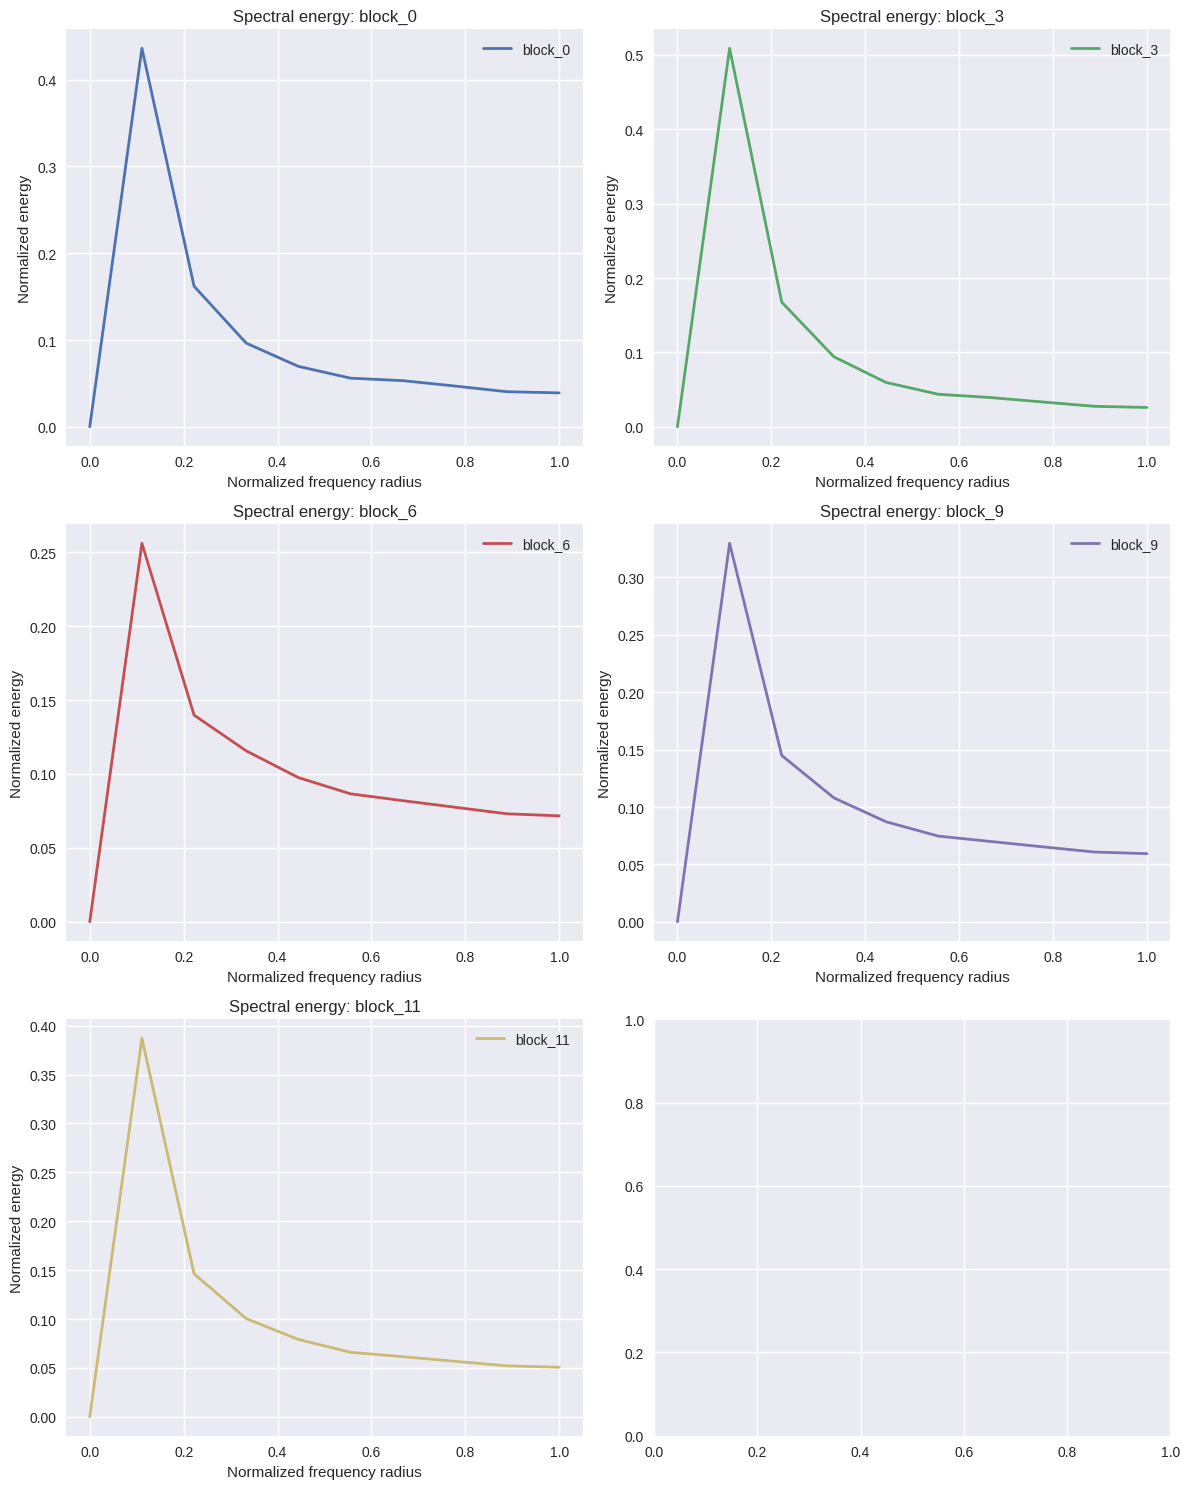

In [48]:
plot_spectra(spectra_vit_s_16, save_path=f"{SAVE_PATH}vit_s_16_imagenet_spectra.png")
np.savez(f"{SAVE_PATH}vit_s_16.npz", **spectra_vit_s_16)

/home/shamighoul/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


2 
42 
82 
122 
162 
202 
242 
282 


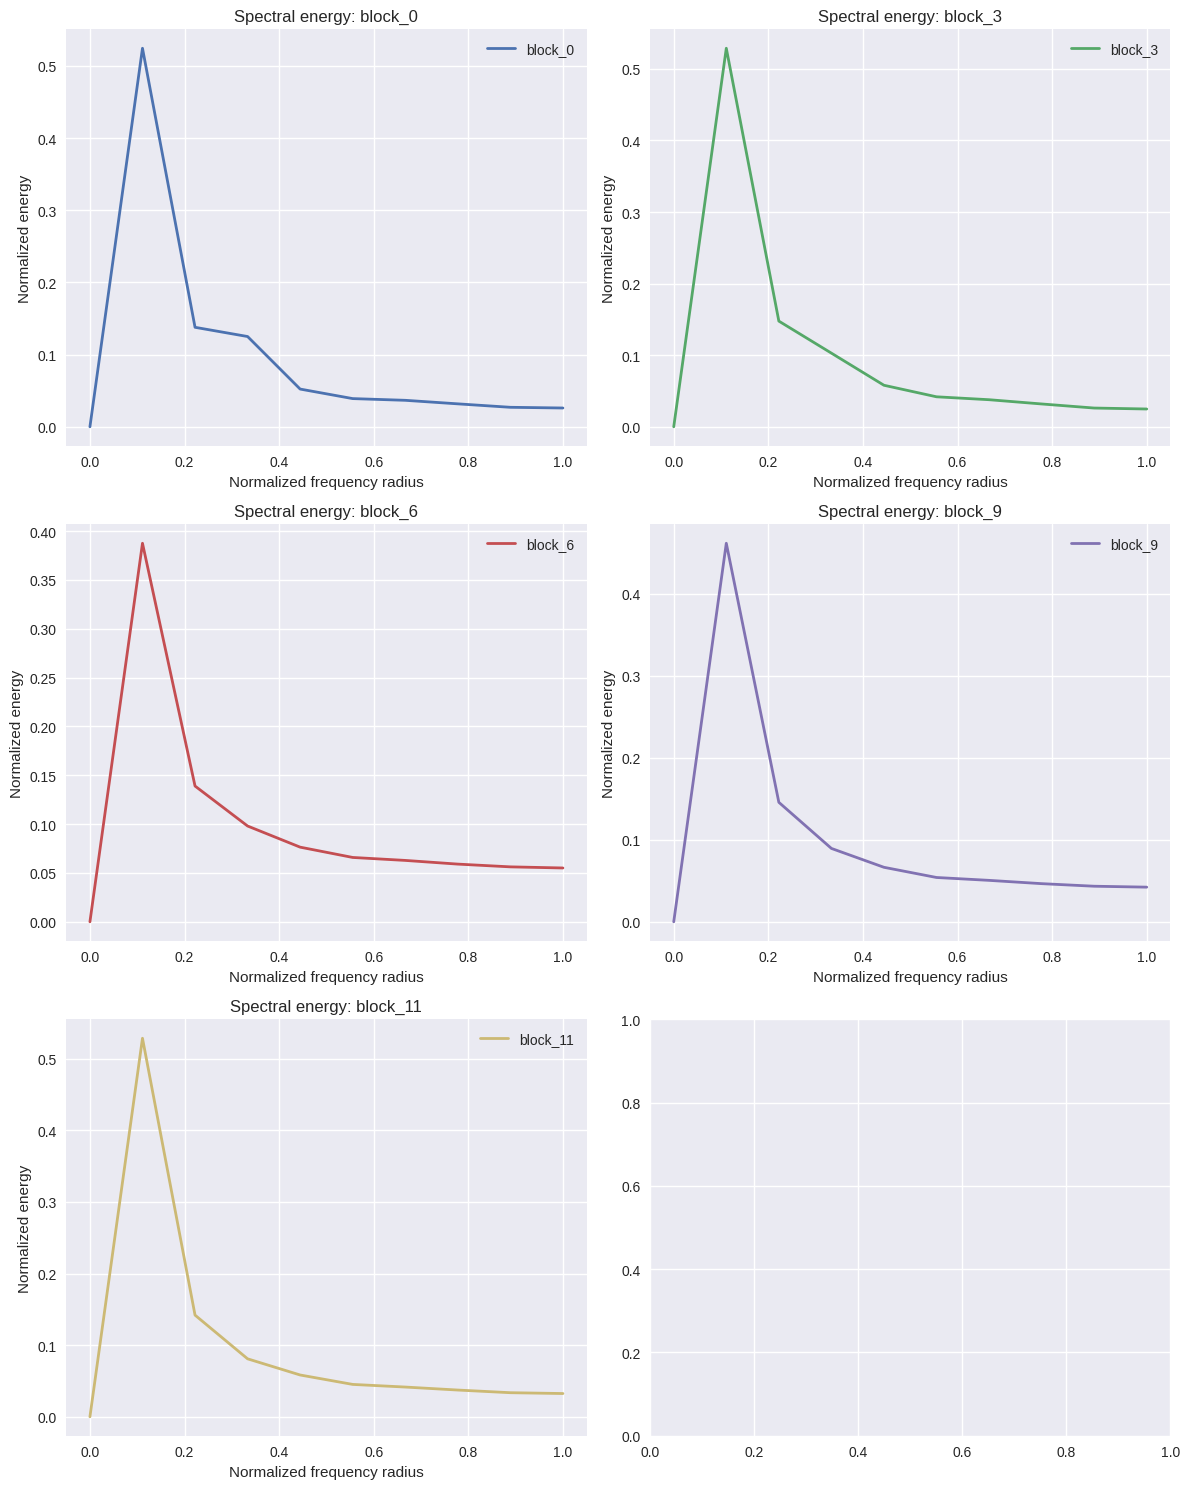

In [49]:
val_loader = get_imagenet_val_loader(IMAGENET_DIR, BATCH_SIZE, NUM_WORKERS)
base_base_model = timm.create_model('vit_base_patch16_224', pretrained=True).to(DEVICE)
base_model = HookedVit(base_base_model).to(DEVICE)

spectra_vit_b_16 = collect_spectra(base_model, val_loader, DEVICE, MAX_BATCHES)
np.savez(f"{SAVE_PATH}vit_b_16.npz", **spectra_vit_b_16)
plot_spectra(spectra_vit_b_16, save_path=f"{SAVE_PATH}vit_b_16_imagenet_spectra.png")

/home/shamighoul/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


2 
42 
82 
122 
162 
202 
242 
282 


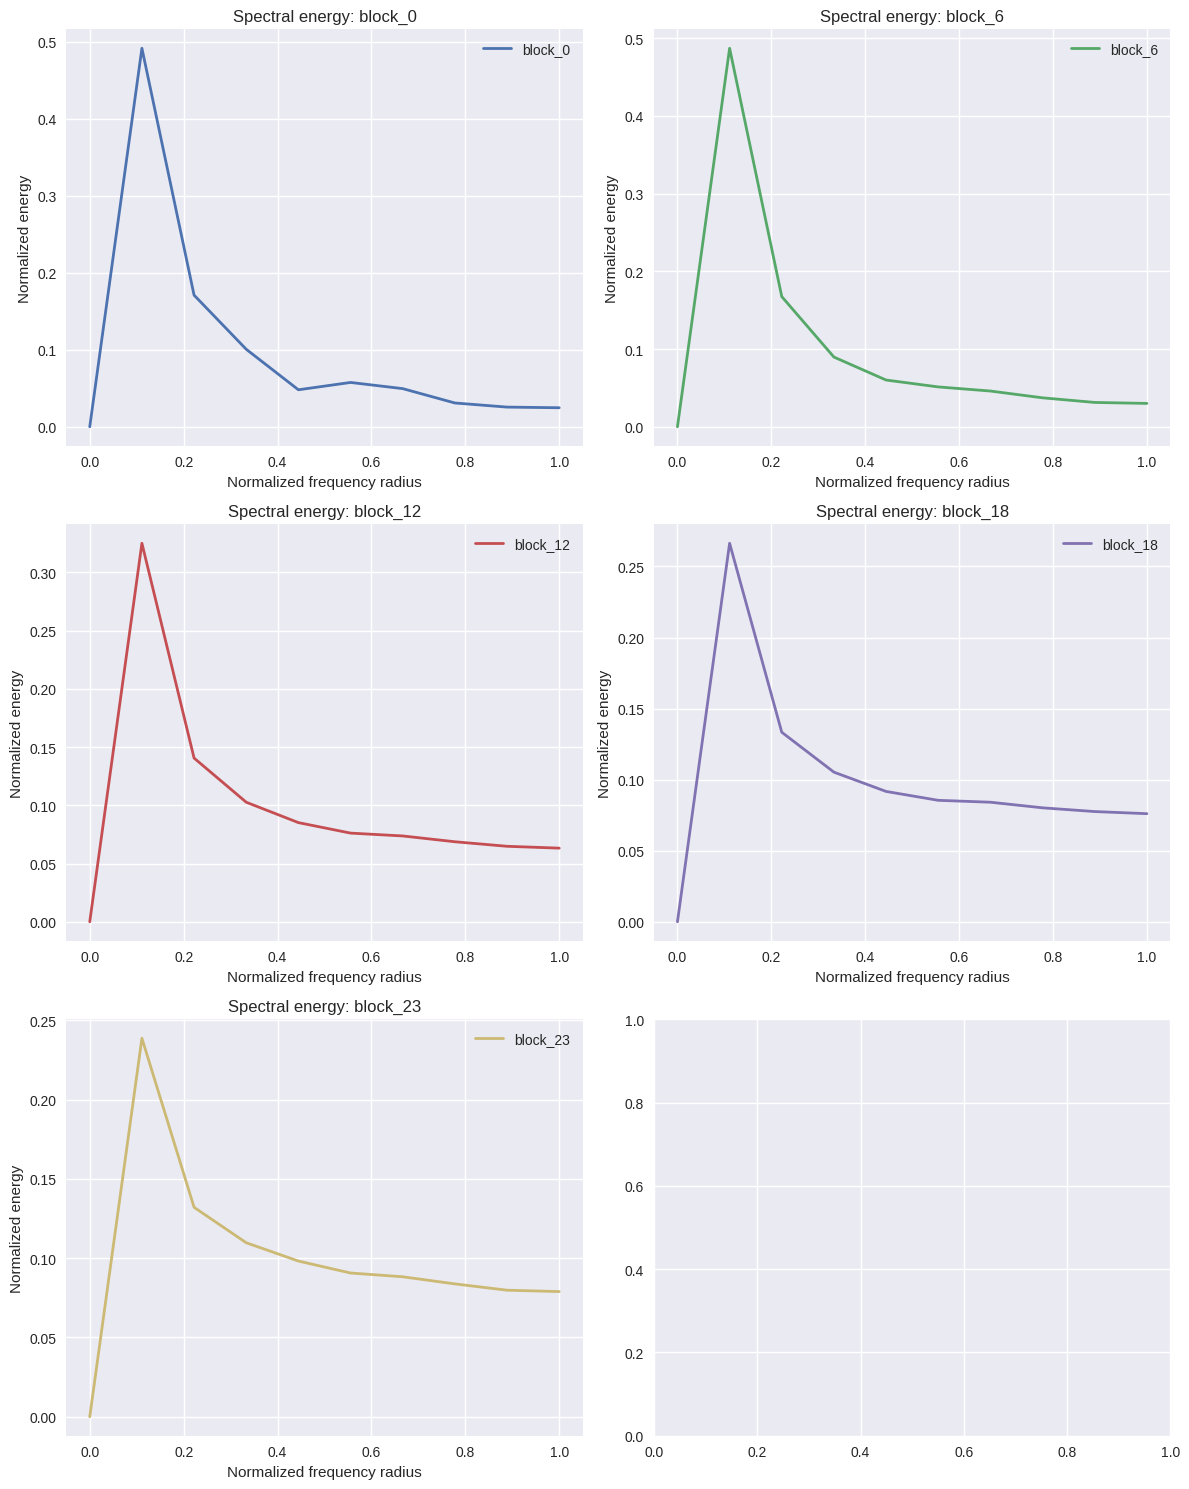

In [50]:
val_loader = get_imagenet_val_loader(IMAGENET_DIR, BATCH_SIZE, NUM_WORKERS)
base_large_model = timm.create_model('vit_large_patch16_224', pretrained=True).to(DEVICE)
large_model = HookedVit(base_large_model).to(DEVICE)

spectra_vit_l_16 = collect_spectra(large_model, val_loader, DEVICE, MAX_BATCHES)
np.savez(f"{SAVE_PATH}vit_l_16.npz", **spectra_vit_l_16)
plot_spectra(spectra_vit_l_16, save_path=f"{SAVE_PATH}vit_l_16_imagenet_spectra.png")

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

/home/shamighoul/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


2 
42 
82 
122 
162 
202 
242 
282 


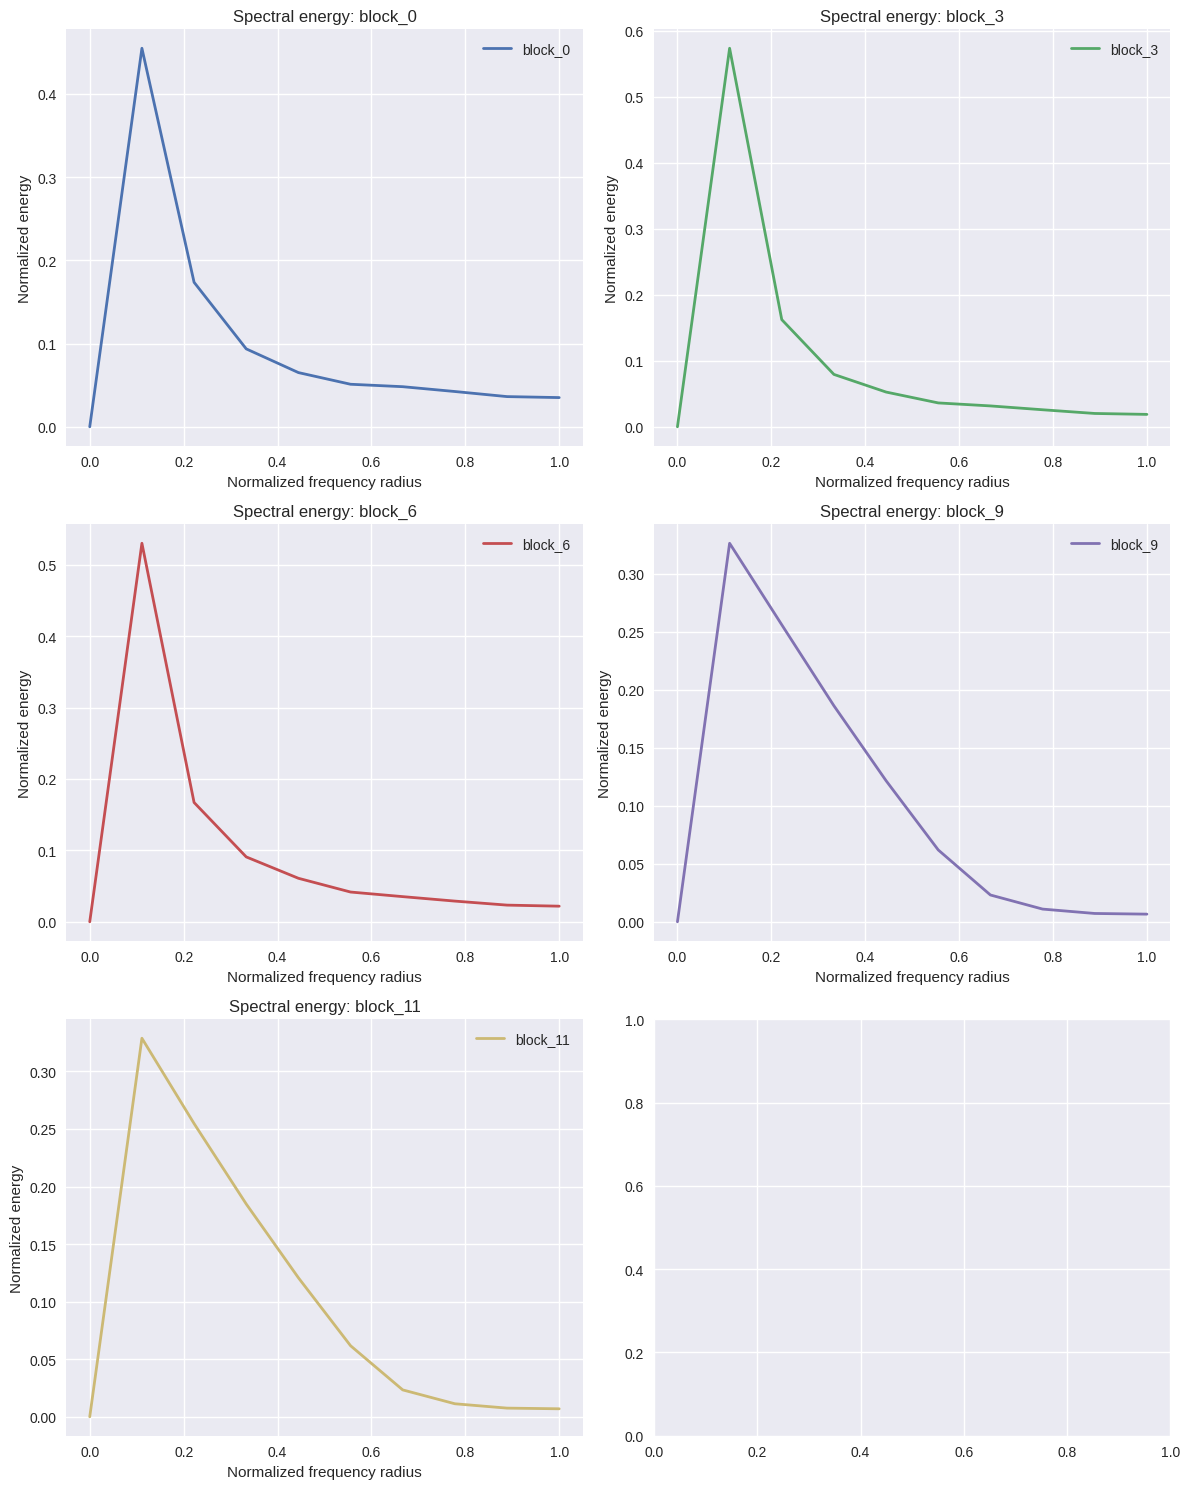

In [51]:
val_loader = get_imagenet_val_loader(IMAGENET_DIR, BATCH_SIZE, NUM_WORKERS)
base_tiny_model = timm.create_model('vit_tiny_patch16_224', pretrained=True).to(DEVICE)
tiny_model = HookedVit(base_tiny_model).to(DEVICE)

spectra_vit_t_16 = collect_spectra(tiny_model, val_loader, DEVICE, MAX_BATCHES)
np.savez(f"{SAVE_PATH}vit_t_16.npz", **spectra_vit_t_16)
plot_spectra(spectra_vit_t_16, save_path=f"{SAVE_PATH}vit_t_16_imagenet_spectra.png")

In [ ]:
for _ in range(60):
    os.system('echo -e "\a"')
    time.sleep(0.5)

## Все снятые слои для каждой модели

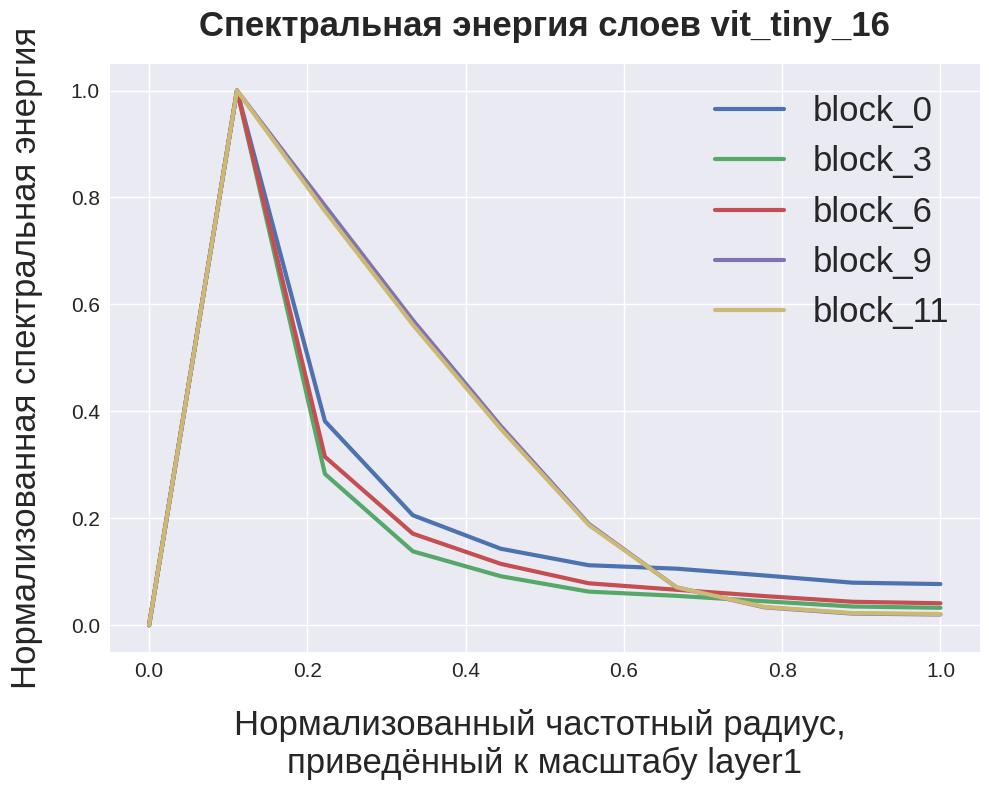

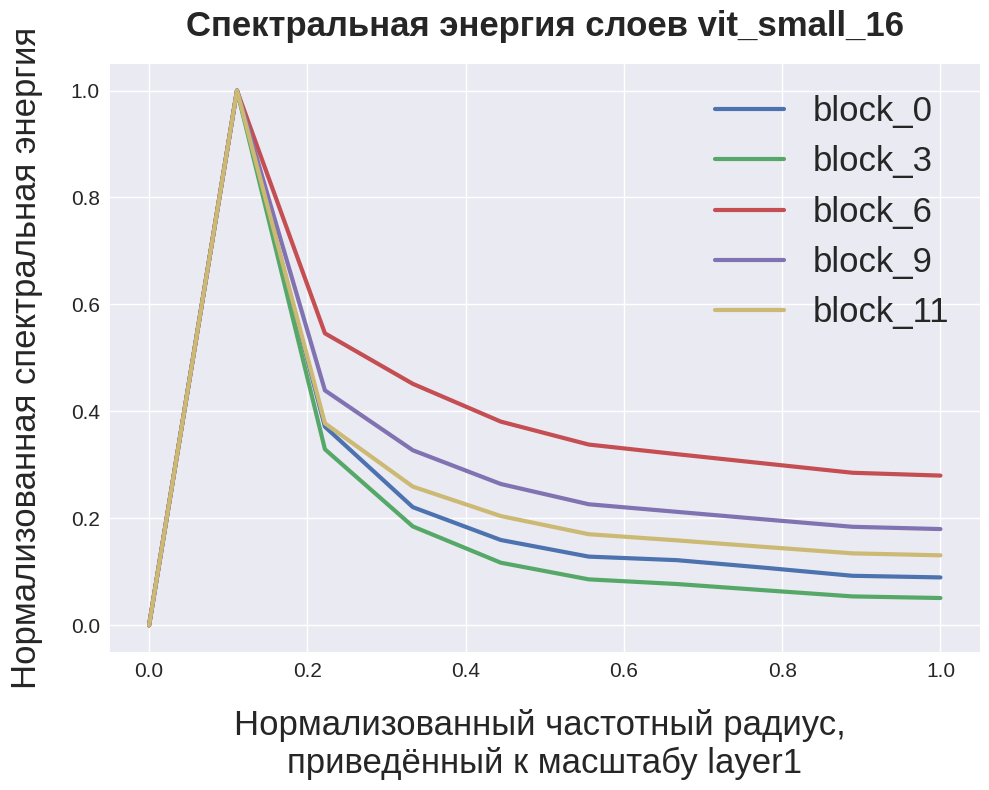

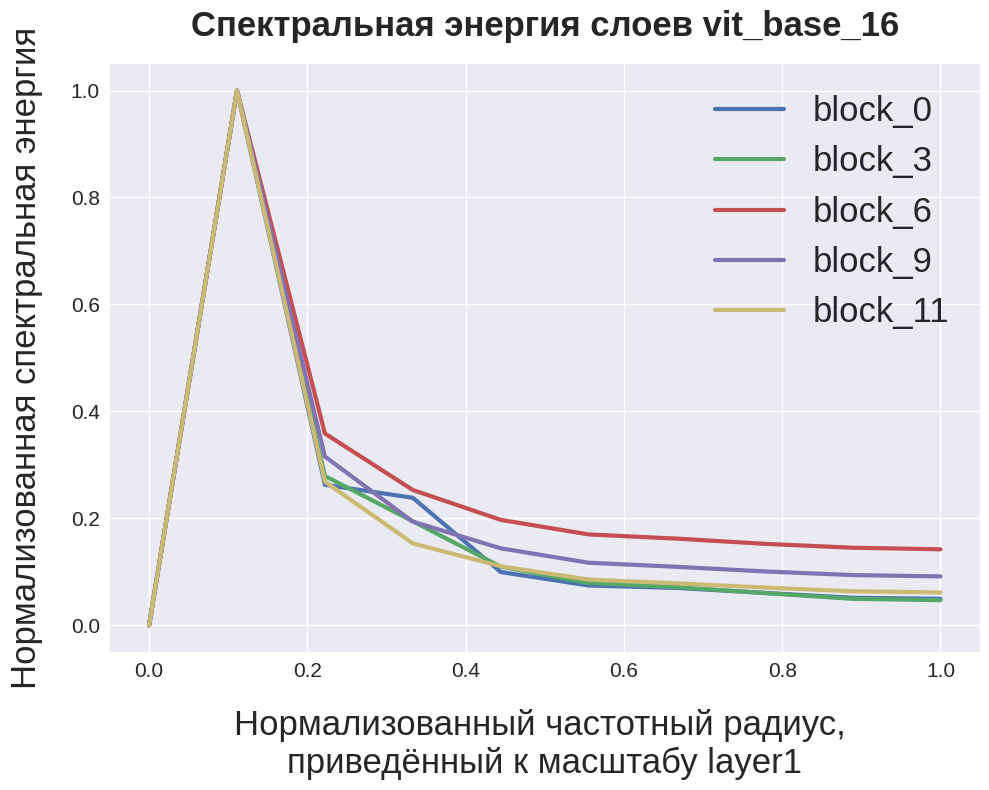

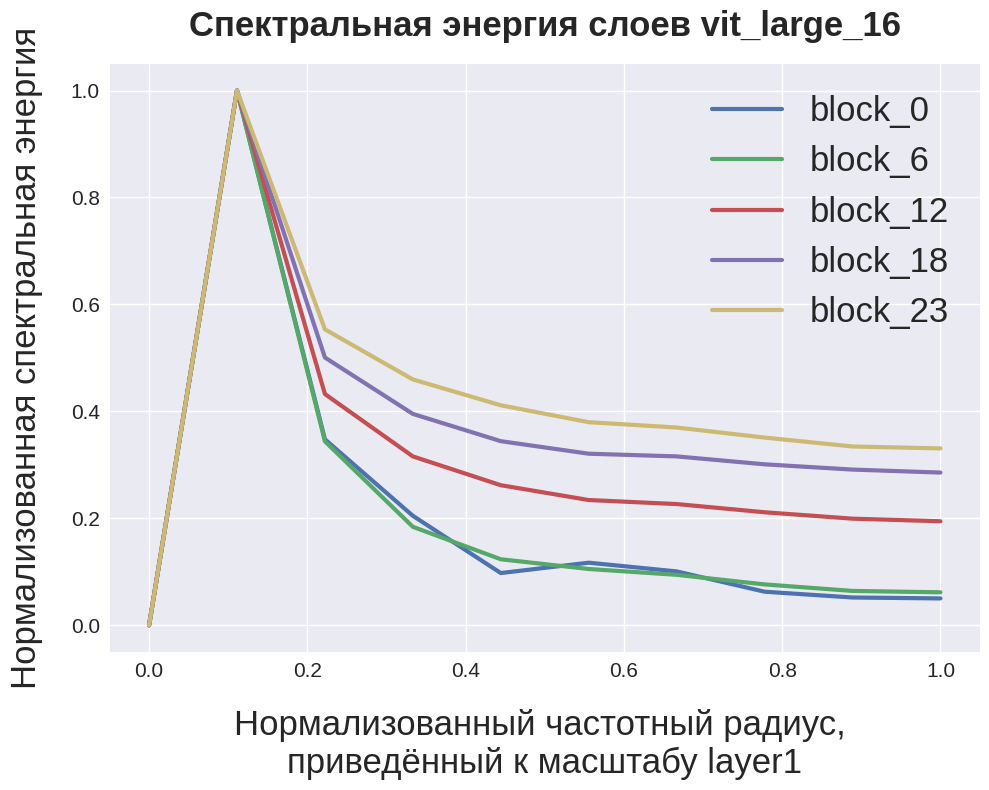

In [34]:
plot_spectra_compare("vit_tiny_16", spectra_vit_t_16, save_path=f"{SAVE_PATH}compare/vit_t_16_imagenet_spectra.png")
plot_spectra_compare("vit_small_16", spectra_vit_s_16, save_path=f"{SAVE_PATH}compare/vit_s_16_imagenet_spectra.png")
plot_spectra_compare("vit_base_16", spectra_vit_b_16, save_path=f"{SAVE_PATH}compare/vit_b_16_imagenet_spectra.png")
plot_spectra_compare("vit_large_16", spectra_vit_l_16, save_path=f"{SAVE_PATH}compare/vit_l_16_imagenet_spectra.png")

## На разных слоях как видут себя Vit

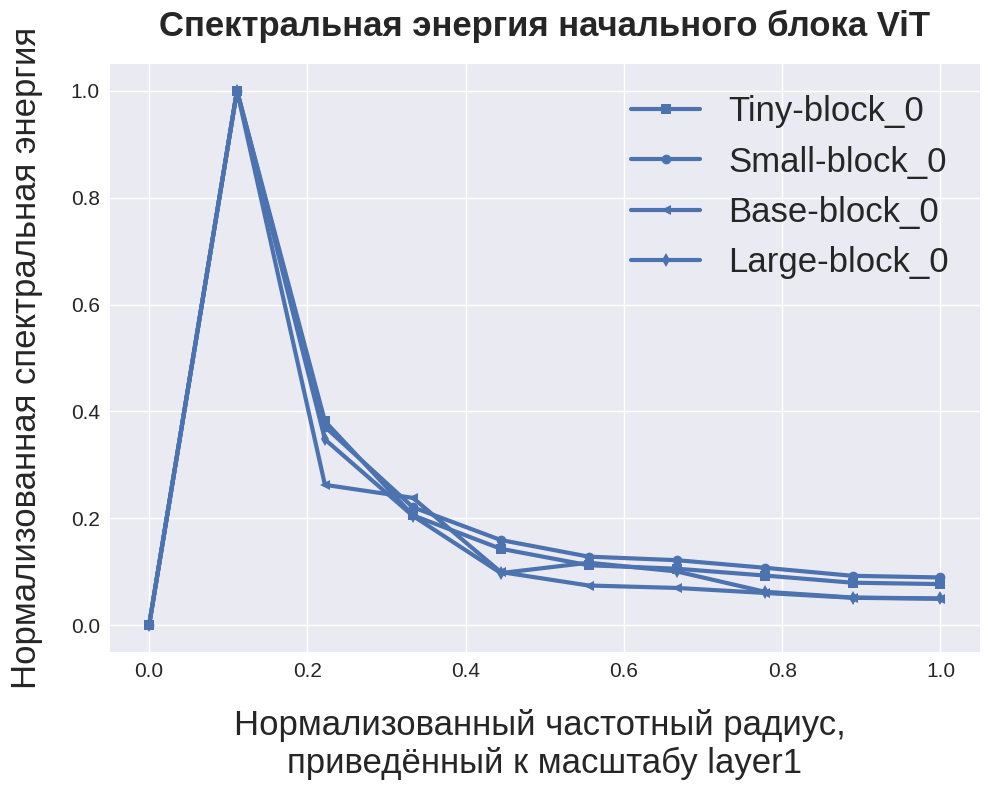

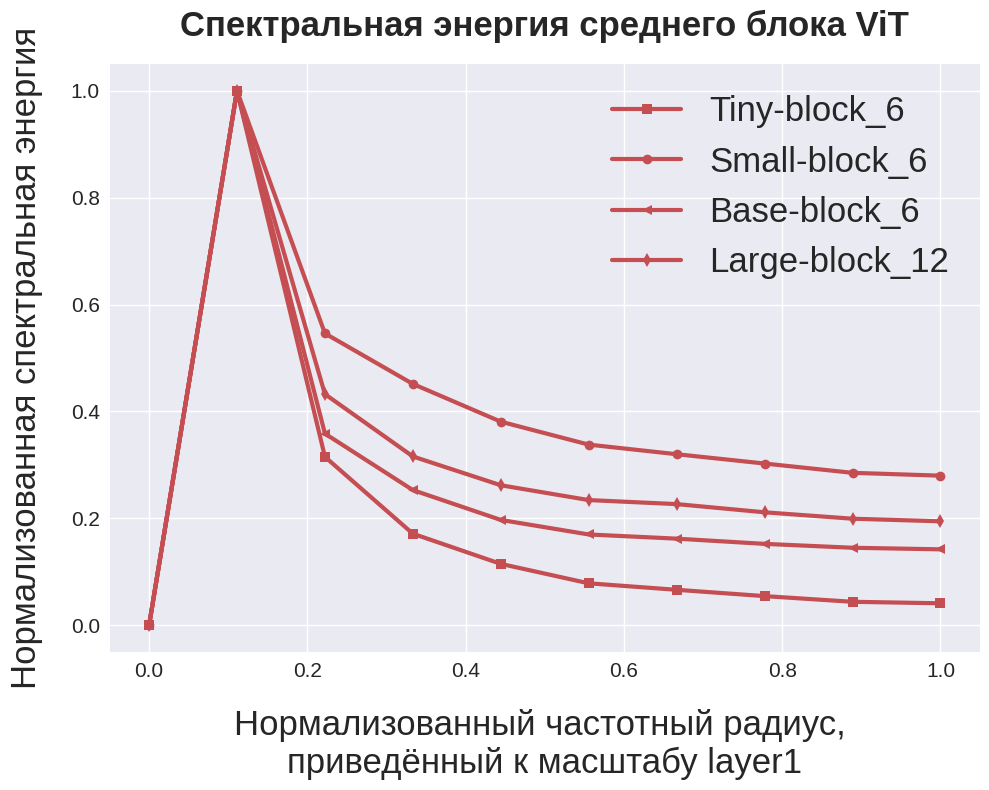

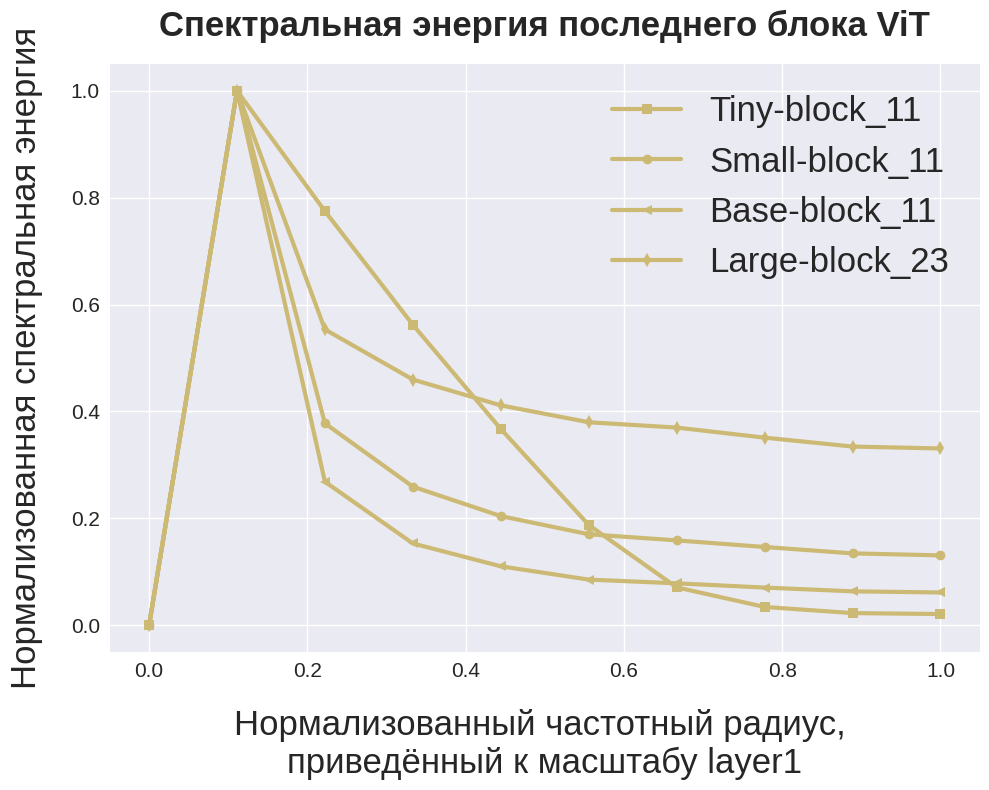

In [39]:
plot_spectra_compare_in_layer(models_dict, "начального", save_path=f"{SAVE_PATH}compare/vit_block_0.png")
plot_spectra_compare_in_layer(models_dict, "среднего", save_path=f"{SAVE_PATH}compare/vit_block_middle.png")
plot_spectra_compare_in_layer(models_dict, "последнего", save_path=f"{SAVE_PATH}compare/vit_block_last.png")

## Метрики для численного сравнения


In [31]:
resolutions = {layer: len(curve) for layer, curve in spectra_vit_t_16.items()}
metrics_vit_tiny = pd.DataFrame(compute_metrics(spectra_vit_t_16, resolutions)).T
metrics_vit_tiny.columns = ["centroid", "low_frac", "high_frac"]
metrics_vit_tiny

,centroid,low_frac,high_frac
block_0,0.297156,55.559078,21.907909
block_3,0.240122,68.047423,13.907346
block_6,0.256731,63.520717,15.836932
block_9,0.278120,44.511902,12.651154
block_11,0.278120,44.734132,12.745176


In [32]:
resolutions = {layer: len(curve) for layer, curve in spectra_vit_s_16.items()}
metrics_vit_small = pd.DataFrame(compute_metrics(spectra_vit_s_16, resolutions)).T
metrics_vit_small.columns = ["centroid", "low_frac", "high_frac"]
metrics_vit_small

,centroid,low_frac,high_frac
block_0,0.311640,53.146669,24.203697
block_3,0.268640,61.231654,17.654469
block_6,0.419165,32.778716,39.591101
block_9,0.376489,40.970569,33.554014
block_11,0.345585,47.254419,29.254722


In [33]:
resolutions = {layer: len(curve) for layer, curve in spectra_vit_b_16.items()}
metrics_vit_base = pd.DataFrame(compute_metrics(spectra_vit_b_16, resolutions)).T
metrics_vit_base.columns = ["centroid", "low_frac", "high_frac"]
metrics_vit_base

,centroid,low_frac,high_frac
block_0,0.264733,61.867951,16.573496
block_3,0.263564,62.697135,16.914928
block_6,0.351339,47.032215,30.313646
block_9,0.308476,55.330170,24.123936
block_11,0.275160,62.468857,19.509458


In [34]:
resolutions = {layer: len(curve) for layer, curve in spectra_vit_l_16.items()}
metrics_vit_large = pd.DataFrame(compute_metrics(spectra_vit_l_16, resolutions)).T
metrics_vit_large.columns = ["centroid", "low_frac", "high_frac"]
metrics_vit_large

,centroid,low_frac,high_frac
block_0,0.274828,59.497642,19.423711
block_6,0.282716,58.835290,20.216346
block_12,0.384705,40.293558,35.122514
block_18,0.422821,33.657102,40.676448
block_23,0.436809,30.602630,42.540773


In [35]:
print(compute_slope(metrics_vit_tiny["centroid"]))
print(compute_slope(metrics_vit_small["centroid"]))
print(compute_slope(metrics_vit_base["centroid"]))
print(compute_slope(metrics_vit_large["centroid"]))

-4.449291549215662e-07
-0.0485479790826708
-0.02105894082211418
-0.12606704683017786


In [51]:
df_result = pd.concat([metrics_vit_tiny,
                       metrics_vit_small,
                       metrics_vit_base,
                      metrics_vit_large], axis=0,
                     keys=["metrics_vit_tiny",
                           "metrics_vit_small",
                           "metrics_vit_base",
                           "metrics_vit_large"])
df_result

centroid   low_frac  high_frac
metrics_vit_tiny  block_0   0.297156  55.559078  21.907909
                  block_3   0.240122  68.047423  13.907346
                  block_6   0.256731  63.520717  15.836932
                  block_9   0.278120  44.511902  12.651154
                  block_11  0.278120  44.734132  12.745176
metrics_vit_small block_0   0.311640  53.146669  24.203697
                  block_3   0.268640  61.231654  17.654469
                  block_6   0.419165  32.778716  39.591101
                  block_9   0.376489  40.970569  33.554014
                  block_11  0.345585  47.254419  29.254722
metrics_vit_base  block_0   0.264733  61.867951  16.573496
                  block_3   0.263564  62.697135  16.914928
                  block_6   0.351339  47.032215  30.313646
                  block_9   0.308476  55.330170  24.123936
                  block_11  0.275160  62.468857  19.509458
metrics_vit_large block_0   0.274828  59.497642  19.423711
                  block_6   0.282716  58.835290  20.216346
                  block_12  0.384705  40.293558  35.122514
                  block_18  0.422821  33.657102  40.676448
                  block_23  0.436809  30.602630  42.540773

## Поиграемся с погрешностью - черновик грязь не нужен


In [7]:
# -------------------------------
# 6. Run Spectral Analysis
# -------------------------------
def collect_all_spectra(model, loader, device, max_batches):
    model.eval()
    spectra = {}
    processed = 0

    with torch.no_grad():
        cnt = 0
        for images, _ in loader:
            cnt += 1
            if cnt%40==2: print(f'{cnt} ')
            images = images.to(device)
            _ = model(images) 
            
            feats = model.get_features()
            
            for name, feat in feats.items():
                # feat: (B, N, D)
                # Преобразуем в 2D карту (B, H, W, D)
                feat_2d = model.patches_to_2d(feat)
                
                # Вычитаем среднее по пространству (H, W) для каждого канала
                spatial_mean = feat_2d.mean(dim=(1, 2), keepdim=True)  # (B, 1, 1, D)
                feat_centered = feat_2d - spatial_mean
                
                # Меняем форму для compute_fft_power: из (B, H, W, D) в (B, D, H, W)
                # потому что compute_fft_power ожидает (B, C, H, W)
                feat_centered = feat_centered.permute(0, 3, 1, 2)  # (B, D, H, W)
                
                # Считаем спектр (используем ту же функцию, что для ResNet)
                power_2d = compute_fft_power(feat_centered)  # (H, W)
                
                # Радиальное усреднение
                curve = radial_average(power_2d)
                spectra.setdefault(name, []).append(curve)

            if cnt >= max_batches:
                break


    return spectra

# -------------------------------
# 7. Metrics
# -------------------------------
def compute_metrics_with_uncertainty(all_spectra, resolutions, ref_layer='block_0',
                                      low_thresh=0.2, high_thresh=0.5, num_points=1000):
    ref_res = resolutions[ref_layer]
    r_common = np.linspace(0, 1, num_points)
    
    metrics_summary = {}
    all_metrics = {'centroid': {}, 'low_frac': {}, 'high_frac': {}}
    
    for layer, curves in all_spectra.items():
        centroids = []
        low_fracs = []
        high_fracs = []
        
        for curve in curves:
            # Нормализация
            curve_norm = curve / np.sum(curve)
            L = len(curve)
            r_orig = np.arange(L) / (L - 1)
            
            # Масштабирование
            scale = resolutions[layer] / ref_res
            r_mapped = r_orig * scale
            
            # Интерполяция
            interp_func = interp1d(r_mapped, curve_norm, kind='linear',
                                   bounds_error=False, fill_value=0.0)
            curve_interp = interp_func(r_common)
            
            # Центроид
            centroid = np.sum(r_common * curve_interp) / np.sum(curve_interp)
            centroids.append(centroid)
            
            # Low fraction
            low_mask = r_common < low_thresh
            low_frac = np.sum(curve_interp[low_mask])
            low_fracs.append(low_frac)
            
            # High fraction
            high_mask = r_common > high_thresh
            high_frac = np.sum(curve_interp[high_mask])
            high_fracs.append(high_frac)
        
        # Сохраняем статистику
        metrics_summary[layer] = {
            'centroid': (np.mean(centroids), np.std(centroids)),
            'low_frac': (np.mean(low_fracs), np.std(low_fracs)),
            'high_frac': (np.mean(high_fracs), np.std(high_fracs)),
            'n_samples': len(centroids)
        }
        
        all_metrics['centroid'][layer] = centroids
        all_metrics['low_frac'][layer] = low_fracs
        all_metrics['high_frac'][layer] = high_fracs
    
    return metrics_summary, all_metrics, r_common

# -------------------------------
# 7. Plotting
# -------------------------------
def plot_spectra(spectra_dict, save_path=None):
    plt.style.use("seaborn-v0_8")
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    axs = axs.ravel()
    blocks = ["layer1", "layer2", "layer3", "layer4"]

    for i, blk in enumerate(blocks):
        if blk in spectra_dict:
            curve = spectra_dict[blk]
            x = np.arange(len(curve)) / max(1, (len(curve) - 1))
            axs[i].plot(x, curve, label=blk, color=f"C{i}", linewidth=2, alpha=0.05)
            axs[i].set_title(f"Spectral energy: {blk}")
            axs[i].set_xlabel("Normalized frequency radius")
            axs[i].set_ylabel("Normalized energy")
            axs[i].grid(True)
            # axs[i].legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

# main()

In [11]:
val_loader = get_imagenet_val_loader(IMAGENET_DIR, BATCH_SIZE, NUM_WORKERS)
MAX_BATCHES = 1000

base_small_model = timm.create_model('vit_small_patch16_224', pretrained=True).to(DEVICE)
small_model = HookedVit(base_small_model).to(DEVICE)

base_base_model = timm.create_model('vit_base_patch16_224', pretrained=True).to(DEVICE)
base_model = HookedVit(base_base_model).to(DEVICE)

base_large_model = timm.create_model('vit_large_patch16_224', pretrained=True).to(DEVICE)
large_model = HookedVit(base_large_model).to(DEVICE)

base_tiny_model = timm.create_model('vit_tiny_patch16_224', pretrained=True).to(DEVICE)
tiny_model = HookedVit(base_tiny_model).to(DEVICE)

In [12]:
all_spectra_vit_s_16 = collect_all_spectra(small_model, val_loader, DEVICE, MAX_BATCHES)

2 
42 
82 
122 
162 
202 
242 
282 


In [13]:
all_spectra_vit_b_16 = collect_all_spectra(base_model, val_loader, DEVICE, MAX_BATCHES)

2 
42 
82 
122 
162 
202 
242 
282 


In [ ]:
all_spectra_vit_l_16 = collect_all_spectra(large_model, val_loader, DEVICE, MAX_BATCHES)

2 
42 
82 
122 


In [ ]:
all_spectra_vit_t_16 = collect_all_spectra(tiny_model, val_loader, DEVICE, MAX_BATCHES)

In [ ]:
np.savez(f"all/vit_t_16.npz", **all_spectra_vit_t_16)
np.savez(f"all/vit_s_16.npz", **all_spectra_vit_s_16)
np.savez(f"all/vit_b_16.npz", **all_spectra_vit_b_16)
np.savez(f"all/vit_l_16.npz", **all_spectra_vit_l_16)

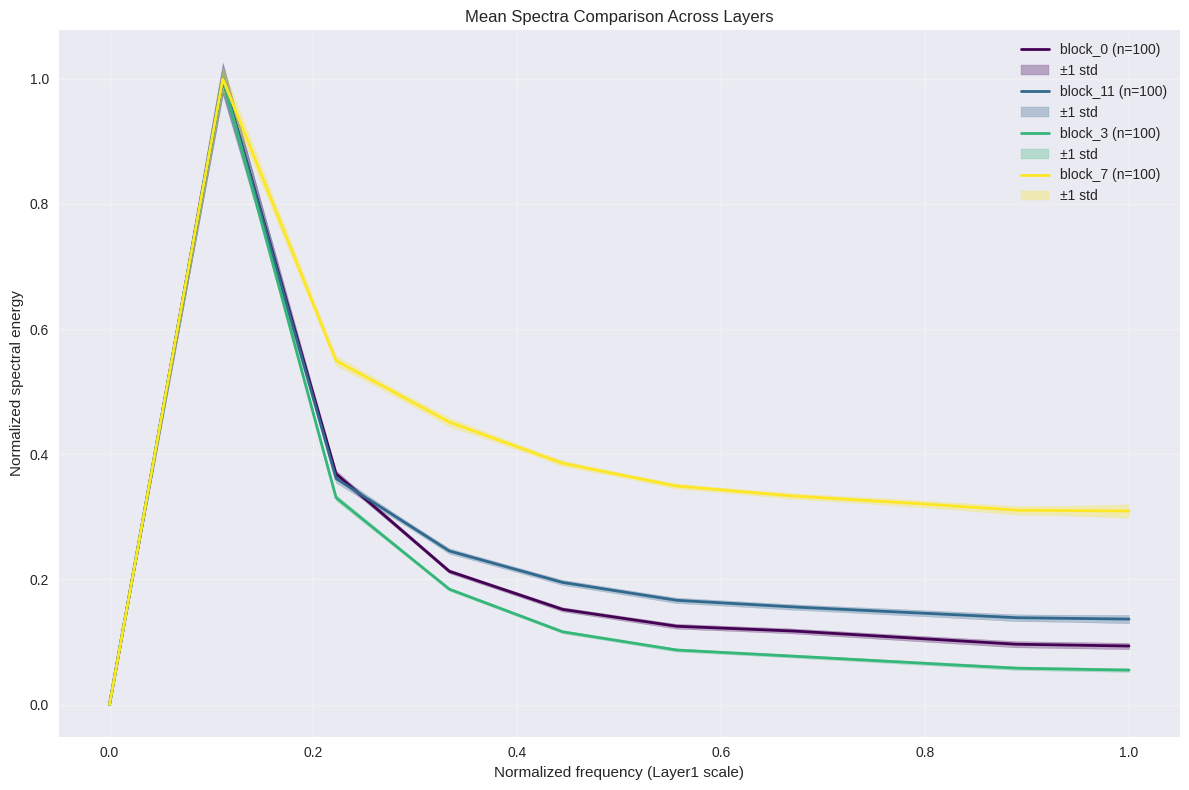

In [229]:
def interpolate_spectrum_to_common_grid(curve, resolution, ref_res, num_points=1000):
    """
    Интерполирует спектр на общую сетку частот.
    
    Параметры:
        curve: array - радиальный спектр
        resolution: int - разрешение слоя
        ref_res: int - разрешение эталонного слоя
        num_points: int - количество точек в целевой сетке
    
    Возвращает:
        r_common: array - общая сетка частот
        curve_interp: array - интерполированный спектр
    """
    # Нормализация
    curve_norm = curve / np.sum(curve)
    
    # Исходные частоты
    L = len(curve)
    r_orig = np.arange(L) / (L - 1)
    
    # Масштабирование
    scale = resolution / ref_res
    r_mapped = r_orig * scale
    
    # Целевая сетка (только до максимальной доступной частоты)
    max_freq = min(1.0, scale)  # не может быть больше 1
    r_common = np.linspace(0, max_freq, num_points)
    
    # Интерполяция
    interp_func = interp1d(r_mapped, curve_norm, kind='linear', 
                           bounds_error=False, fill_value=0.0)
    curve_interp = interp_func(r_common)
    
    return r_common, curve_interp


def prepare_spectra_for_plotting(all_spectra, resolutions, ref_layer='block_0', num_points=1000):
    """
    Подготавливает все спектры для визуализации: интерполирует на общую сетку.
    
    Возвращает:
        spectra_interp: dict {layer: {'r': array, 'curves': list_of_arrays, 'mean': array, 'std': array}}
    """
    ref_res = resolutions[ref_layer]
    spectra_interp = {}
    
    for layer, curves in all_spectra.items():
        resolution = resolutions[layer]
        
        # Интерполируем все кривые
        interp_curves = []
        r_common = None
        
        for curve in curves:
            r, curve_interp = interpolate_spectrum_to_common_grid(
                curve, resolution, ref_res, num_points
            )
            if r_common is None:
                r_common = r
            interp_curves.append(curve_interp)
        
        # Преобразуем в массив для удобства
        interp_curves = np.array(interp_curves)
        
        spectra_interp[layer] = {
            'r': r_common,
            'curves': interp_curves,
            'mean': np.mean(interp_curves, axis=0),
            'std': np.std(interp_curves, axis=0),
            'n_samples': len(interp_curves)
        }
    
    return spectra_interp


# ============================================================
# 2. Различные типы визуализации
# ============================================================

def plot_all_layers_comparison(spectra_interp, layers=None, title=None, figsize=(12, 8)):
    """
    Сравнивает средние спектры всех слоёв на одном графике.
    
    Параметры:
        spectra_interp: dict от prepare_spectra_for_plotting
        layers: list - список слоёв для отображения (по умолчанию все)
        title: str - заголовок
        figsize: tuple - размер фигуры
    """
    if layers is None:
        layers = list(spectra_interp.keys())
    
    # Сортируем слои по порядку (layer1, layer2, ...)
    layers = sorted(layers)
    
    plt.figure(figsize=figsize)
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(layers)))
    
    for i, layer in enumerate(layers):
        data = spectra_interp[layer]
        r = data['r']
        std = data['std']
        mean = data['mean']/data['mean'].max()
        plt.plot(r, mean, color=colors[i], linewidth=2, label=f"{layer} (n={data['n_samples']})")
        plt.fill_between(r, mean - std, mean + std, 
                     color=colors[i], alpha=0.3, label='±1 std')
    
    if title is None:
        title = "Mean Spectra Comparison Across Layers"
    plt.title(title)
    plt.xlabel("Normalized frequency (Layer1 scale)")
    plt.ylabel("Normalized spectral energy")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_all_layers_comparison(prepare_spectra_for_plotting(spectra, resolutions))

In [233]:
blocks = sorted(spectra.keys(), key=lambda x: int(x.split('_')[1]))
resolutions = {name: len(spectra[name]) for name in blocks}
resolutions
metrics_summary, all_metrics, r_common = compute_metrics_with_uncertainty(spectra, resolutions)

In [234]:
pd.DataFrame(metrics_summary).T

,centroid,low_frac,high_frac,n_samples
block_0,"(0.31178073768862385, 0.014128733647381606)","(53.519003564923615, 2.6185119609622696)","(24.282885803855024, 2.1167919518861154)",100
block_3,"(0.27147789387979926, 0.008521092596643267)","(60.87066775431939, 1.698006368264027)","(18.109465164211873, 1.286440855309442)",100
block_7,"(0.4274108252904565, 0.014515911767004704)","(31.927861686156458, 2.130467424268153)","(40.86470942176496, 2.178010067302622)",100
block_11,"(0.3473858060385823, 0.01549556611247222)","(47.66473045435885, 2.8883098931545734)","(29.715820245462915, 2.2668417393707943)",100
